In [13]:
import numpy as np
import scipy.stats
import scipy.special
import scipy.optimize
import scipy.integrate
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.insert(0, "/home/jovyan/assignments/Bayesian-Stats-HS2026/course_tools/src")

In [14]:
title = "# Introduction to Bayesian statistics: exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)
import numpy as np
import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Introduction to Bayesian statistics: exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

# Exercise 1

- Implement your own version of the line-fitting procedure, using the same data.
- Now try it with the data in `lectures/data/linear_fits/data_1.txt`
    - First plot the data. What has changed?
    - Try the same model and likelihood on the new data. You might want to adjust the prior on $m$ and $b$ for this new data set.
    - What if you use the provided uncertainty per data point $\sigma_{y_i}$, instead of assuming a constant variance $\sigma_y$ for all data points?
    - Instead use the actual likelihood of the data:
\begin{align}
    \mu(x) &= mx + b \\
    \sigma(x_i) &= \sigma_{y_i} + f\mu(x_i)^2 \quad f > 0\ \text{a parameter} \\
    y_i&\sim\mathcal N(\mu(x_i),\sigma(x_i)^2)
\end{align}
Careful with the normalisation of the Gaussian likelihood. Because we vary the variance, this matters now!

In [15]:
def plot_linear_data_set(x, y, y_err=None):
    """Plot linear data set and format the plot."""
    fig, ax = plt.subplots(1, 1)

    if y_err is not None:
        ax.errorbar(x, y, y_err, fmt=".", label="Data")
    else:
        ax.plot(x, y, marker=".", linestyle="none", label="Data")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="upper left")

    return fig, ax

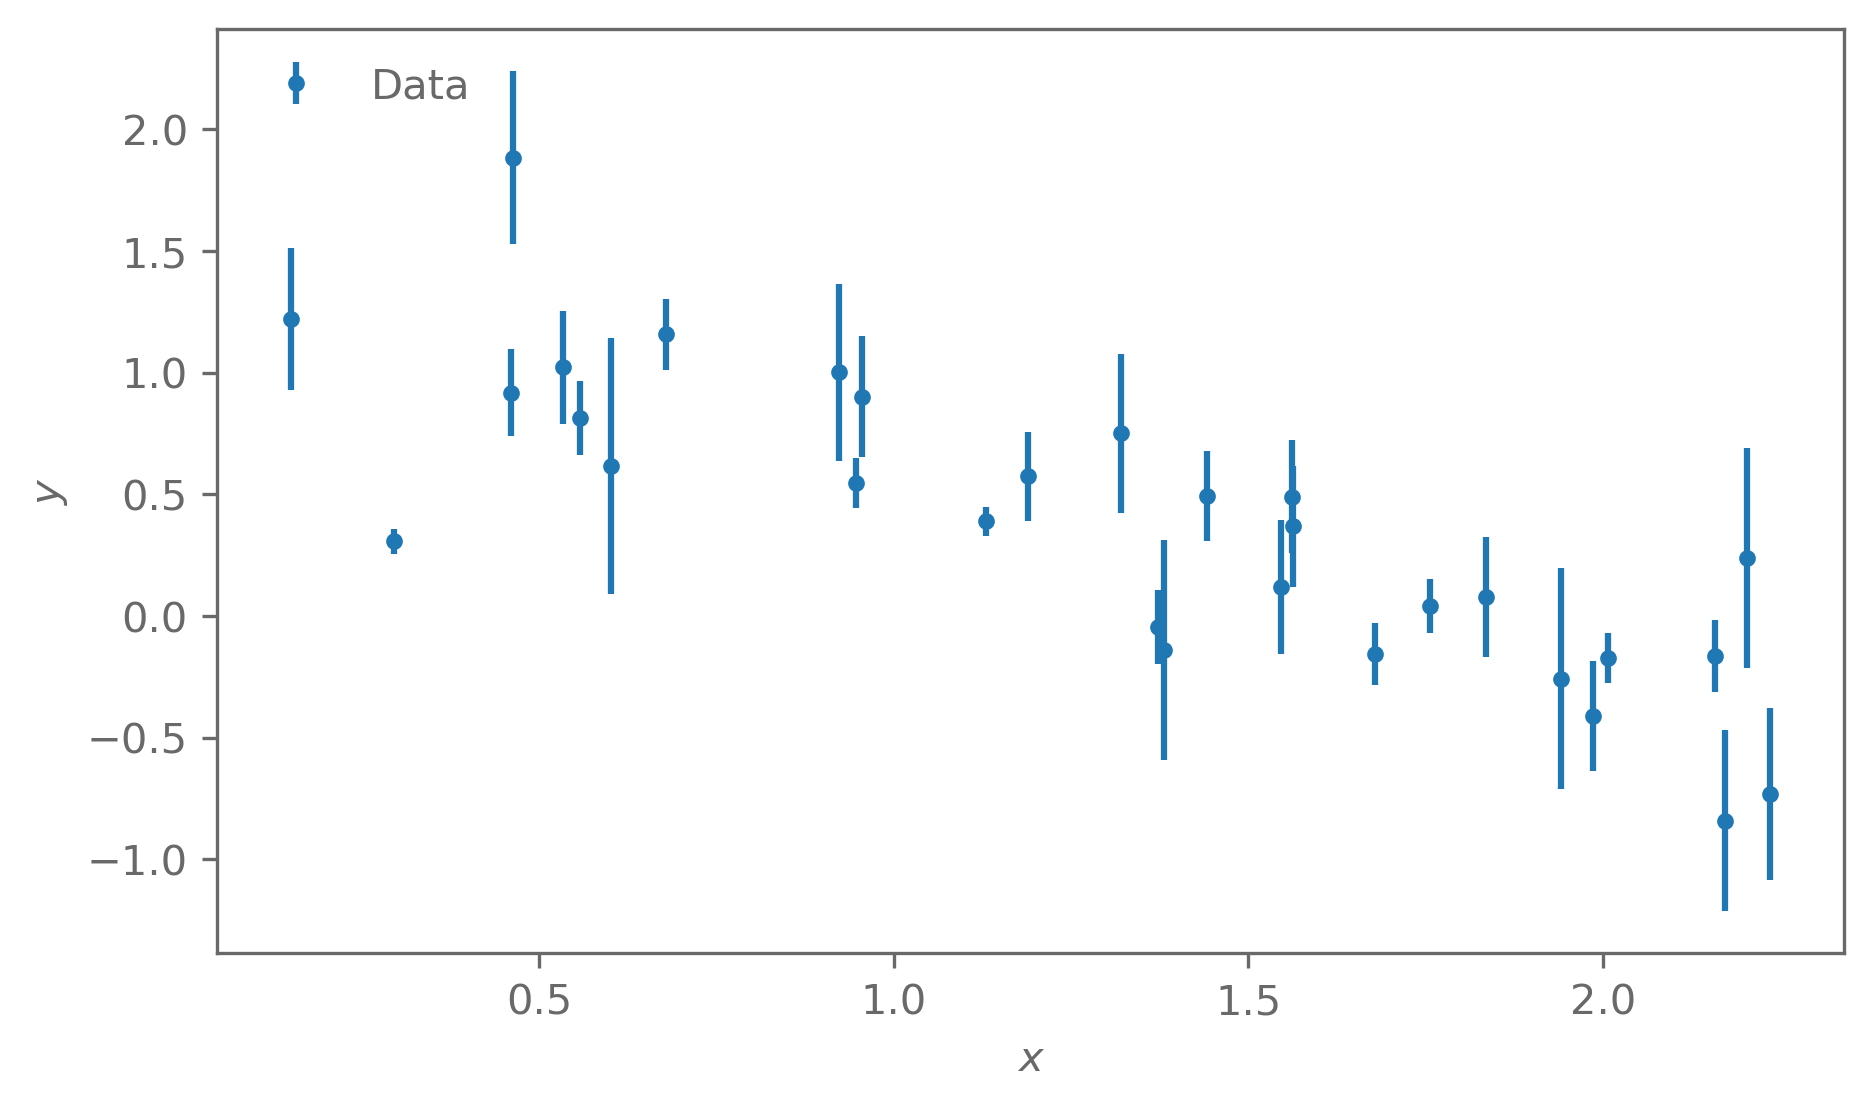

In [21]:
x, y, y_err = np.loadtxt("/home/jovyan/assignments/Bayesian-Stats-HS2026/lectures/data/linear_fits/data_1.txt", unpack=True)
# For now, all errors are the same
#sigma_y = y_err[0]

_ = plot_linear_data_set(x, y, y_err)

### 1. Build a probabilistic model

Let us assume the following model for the data:

The data $y_i$ are Gaussian distributed around a linear model $f(x) = mx + b$, with variances $\sigma_{y_i}^2$.

This model is equivalently characterized by the Gaussian likelihood
$$
y_i | x_i, \theta &\sim\mathcal{N}(\mu(x_i, \theta),\sigma(x_i)^2)
$$
where
\begin{align}
    \mu(x, \theta) &= mx + b, \quad \theta = (m,b), \\
    \sigma(x_i) &= \sigma_{y_i}. \\
\end{align}

Assuming conditional independence of $y_i$ given $x_i, \theta$ allows for the factorization of the likelihood
$$
p(y_{1:n} | x_{1:n}, \theta) = \prod_{i = 1}^n \mathcal{N}(y_i; \mu(x_i, \theta),\sigma(x_i)^2)
$$
where
$$
\mathcal{N}(y_i; \mu(x_i, \theta),\sigma(x_i)^2) =
\frac{1}{\sqrt{ 2 \pi \sigma_{y_{i}}^2 }} \exp\left( -\frac{(y_{i} - \mu(x_{i}, \theta))^2}{2 \sigma_{y_{i}}^2} \right).
$$
The log-likelihood is then
$$
\log p(y_{1:n} | x_{1:n}, \theta) = -\sum_{i = 1}^{n} \left[ \frac{1}{2}\log(2 \pi \sigma_{y_{i}}^2) + \frac{1}{2 \sigma_{y_{i}}^2} (y_{i} - \mu(x_{i}))^2 \right]
$$
This lets us define our probabilistic model:


In [24]:
# The linear model
def model(m, b, x):
    return m*x + b

# Probability of the data, given the model parameters: P(y|m, b)
# We use the logarithm here for computational reasons
def log_likelihood_probability(y, m, b, x, sigma_y):
    mu = model(m, b, x)
    
    # log of the PDF of a multivariate Gaussian
    return (
        -0.5 * np.sum((y - mu)**2/sigma_y**2 + np.log(2*np.pi*sigma_y**2))  
    )

We also need to define a prior. 

Let us assume that we have some prior knowledge:
- $m$ should be around -1 with uncertainty 1: $m\sim\mathcal{N}(-1, 1^2)$
- $b$ should be around 0 with uncertainty 1.2: $b\sim\mathcal{N}(0, 1.75^2)$

In [26]:
m_prior = scipy.stats.norm(loc=-1, scale=1)
b_prior = scipy.stats.norm(loc=0, scale=1.75)

def log_prior_probability(m, b):
    return m_prior.logpdf(m) + b_prior.logpdf(b)

### 2. Fit the model

Now that we have convinced ourselves that the prior model looks reasonable, we can move on the fit the model.

This means evaluating the posterior distribution:

$$
p(\theta|y_{1:n}, x_{1:n}) \propto p(y_{1:n} |\theta, x_{1:n}) \cdot p(\theta),
$$
or equivalently, the log posterior:
$$
\log p(\theta|y_{1:n}, x_{1:n}) \propto \log p(y_{1:n} |\theta, x_{1:n}) + \log p(\theta).
$$

In [27]:
def log_posterior_probability(m, b, x, sigma_y, y):
    return (
        log_likelihood_probability(y, m, b, x, sigma_y)
        + log_prior_probability(m, b)
    )

In [35]:
# The scipy minimizer finds the minimum, so we need to take the 
# negative of the posterior. The scipy minimizer also passes an array 
# with the parameters, this wrapper splits this array into m and b.
def negative_log_posterior(theta, x, sigma_y, y):
    m, b = theta
    return -log_posterior_probability(m, b, x, sigma_y, y)

MAP_result = scipy.optimize.minimize(
    fun=negative_log_posterior,
    x0=(-1, 2),
    args=(x, sigma_y, y)
)
m_MAP, b_MAP = MAP_result.x
# we dont know the true values from the 01 dataset
#m_true = -0.7
#b_true = 1.2

print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")
#print(f"m_true = {m_true:.3f}, b_true = {b_true:.3f}")

MAP results
m_MAP = -0.791, b_MAP = 1.394


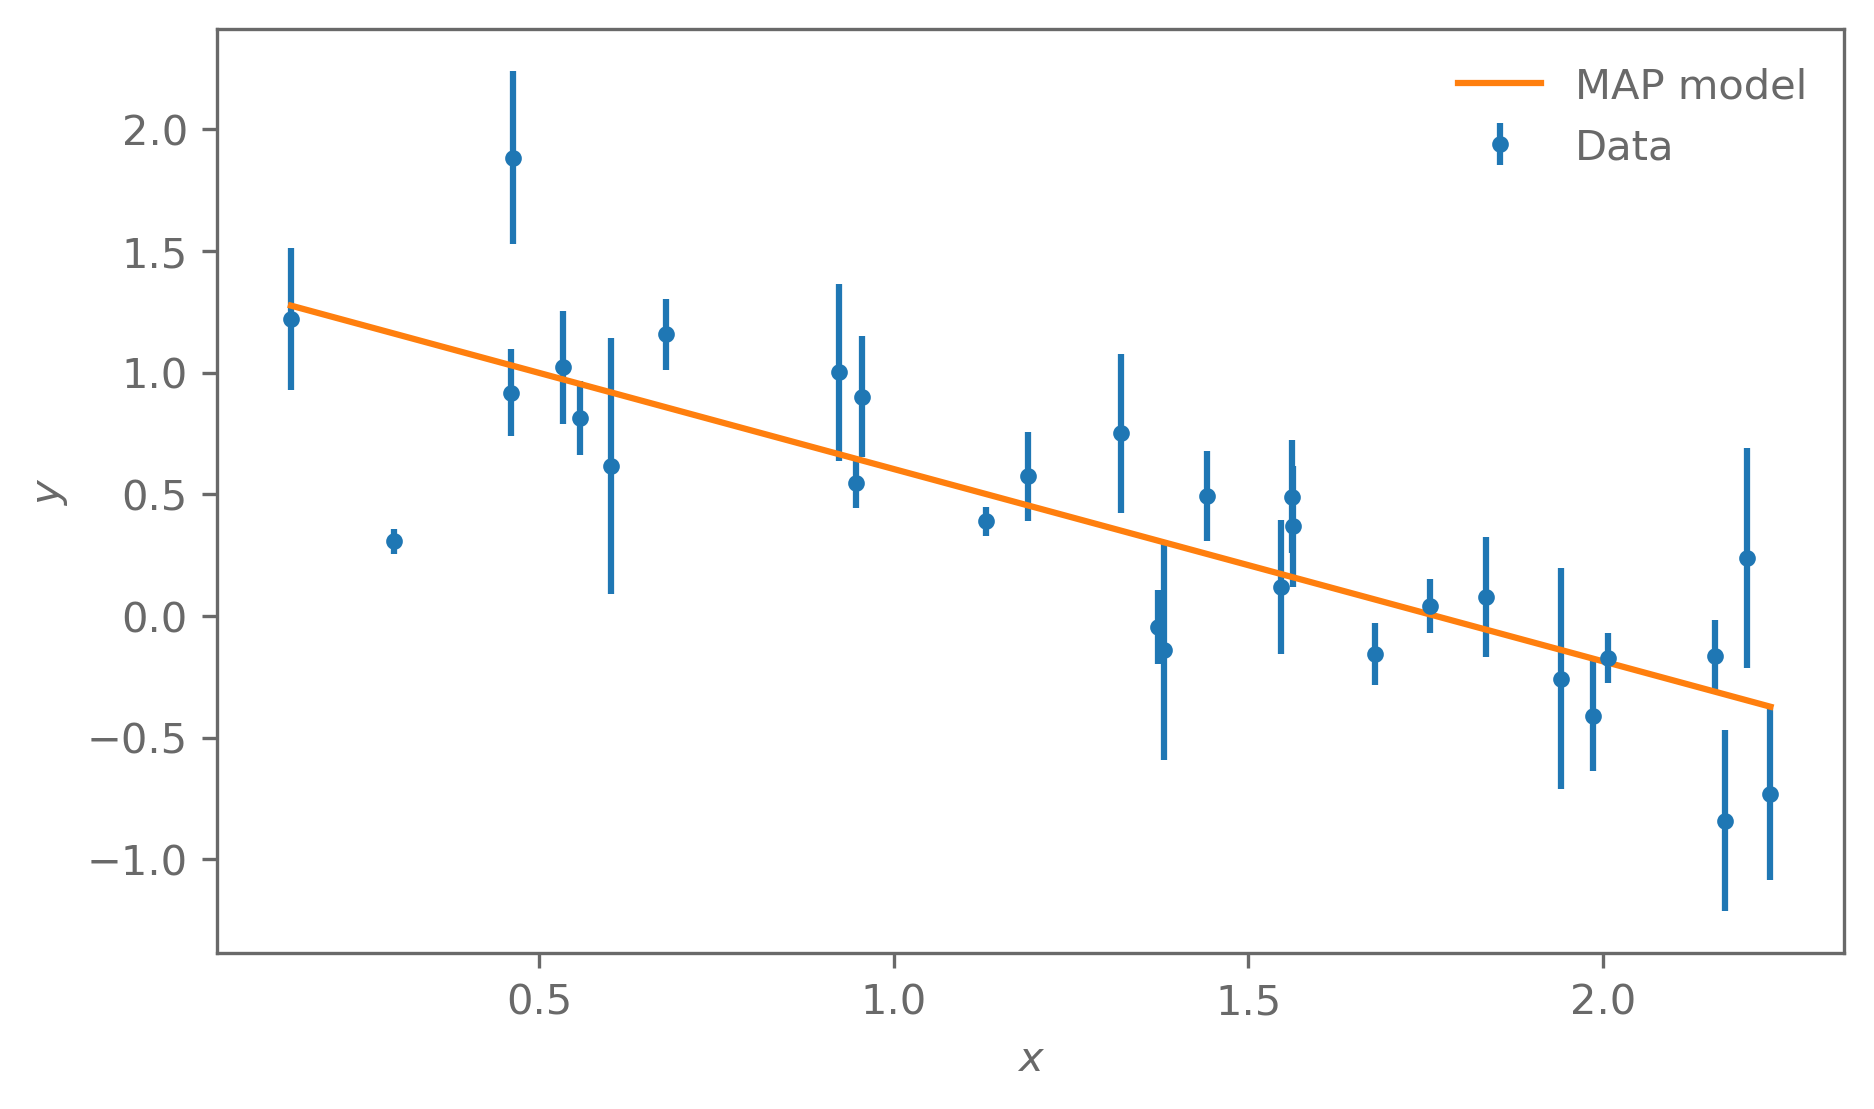

In [36]:
_, ax = plot_linear_data_set(x, y, y_err)

x_grid = np.linspace(0, 2.5, 100)
#ax.plot(x, model(m_true, b_true, x), c="k", ls="--", label="True model")
ax.plot(x, model(m_MAP, b_MAP, x), c="C1", label="MAP model")
ax.legend();

#### MAP

We now defined our posterior, so we can start calculating things with it.

A first step might be to ask, what is the most probable set of parameters $(m, b)$ that describe the data?

For this we need to find the maximum of the posterior. This is called the maximum a-posteriori (MAP) and is the "best-fit" value:
$$
    \theta_\mathrm{MAP} = \underset{\theta}{\mathrm{argmax}}\ p(\theta|d)
$$

# Exercise 2

The data in the previous example were a synthetic version of real observations that were obtained in an AstroWoche project in 2024 by Jonas Spiller, Theo Lequy, Clara Bleich. 

<!-- ![jovian moons data](../assets/jovian_moons_raw_data.png) -->
<img style="display: block; 
    margin-left: auto;
    margin-right: auto;
    width: 60%;"
    src="../assets/jovian_moons_raw_data.png" alt="jovian moons data"/>

The real observations can be found in `data/jovian_moons/{moon}.dat`:

In [34]:
moon = "Io"

t, distance, distance_alt, distance_err = np.loadtxt(
    f"../lectures/data/jovian_moons/{moon}.dat", unpack=True)

1. Repeat the analysis with the real data set. What do you find?

There is another distance estimate provided. The difference between the distance estimates comes from different approaches to converting the measured distance between Jupiter and its moons from the number of pixels to a physical distance in km.

2. How does the analysis look when using this other distance estimate (what I call `distance_alt`)? What about the other moons?



Because there are two distance estimates that do not agree, both of which are based on reasonable approaches, this suggests that there might be a _systematic_ error in the measurements. Systematic errors are usually not random (which means they do not get smaller as you obtain more data). But we could pretend the offset between the two measurements is an estimate of an unaccounted statistical uncertainty. 

3. How does the analysis look when we assume `sigma_d**2 = distance_err**2 + (distance - distance_alt)**2`?



4. Instead of assuming that the uncertainty is underestimated by this offset, we can also model it. Does the model work better if the variance is a free parameter?
